# Multi-dataset: Gene-Gene Covariation Analysis

This example demonstrates how to identify **cross-cell gene-gene covariation** across
multiple FOVs.

The multi-FOV version pools anchor–neighbor cell pairs across all FOVs within a condition,
increasing statistical power for detecting spatially-specific gene correlations.

**Dataset:** CZI Kidney — normal vs autosomal dominant tubulointerstitial kidney disease (ADTKD) (spatial transcriptomics), availabel at https://cellxgene.cziscience.com/collections/8e880741-bf9a-4c8e-9227-934204631d2a 

**Key API:**
- `spatial_query_multi.compute_gene_gene_correlation` — pools all non-anchor motif cell types together
- `spatial_query_multi.compute_gene_gene_correlation_by_type` — tests each non-anchor cell type separately

> **Tip:** For whole-transcriptomic data like this kidney dataset, we'd suggest pre-selecting highly variable
> genes via the `genes` parameter to improve speed and reduce multiple-testing burden.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

from SpatialQuery import spatial_query_multi

## Load Data & Initialize

In [3]:
DATA_DIR = "../data/CZI_kidney"

data_files = os.listdir(DATA_DIR)
adatas = [ad.read_h5ad(os.path.join(DATA_DIR, f)) for f in data_files]

print(f"Loaded {len(adatas)} FOVs")
adatas[0]

Loaded 84 FOVs


AnnData object with n_obs × n_vars = 12906 × 17811
    obs: 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sample', 'tissue_ontology_term_id', 'disease_state', 'sex_ontology_term_id', 'genotype', 'development_stage_ontology_term_id', 'author_cell_type', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_spatial'

In [4]:
# Create condition labels and filter out mitochondrial / unannotated genes
for i, adata in enumerate(adatas):
    adata.obs['disease_state_genotype'] = (
        adata.obs['disease_state'].astype(str) + '_' + adata.obs['genotype'].astype(str)
    )
    adata.var_names = adata.var['feature_name'].tolist()
    adata = adata[:, ~adata.var_names.str.startswith('mt-')]
    adata = adata[:, ~adata.var_names.str.endswith('Rik')]
    adata = adata[:, ~adata.var_names.str.startswith('Gm')]
    adatas[i] = adata

In [5]:
# Map verbose condition names to short labels
dataset_mapping = {
    'early diabetic kidney disease_BTBR-ob/ob': 'DKD_BTBR-ob/ob',
    'autosomal dominant tubulointersital kidney disease (ADTKD)_UMOD-KI/KI': 'ADTKD_UMOD-KI/KI',
    'control_BTBR-wt/wt': 'control_BTBR-WT/WT',
    'control_UMOD-WT/WT': 'control_UMOD-WT/WT',
}

dataset_name_col = 'disease_state_genotype'
datasets = [adata.obs[dataset_name_col].unique()[0] for adata in adatas]
dataset_names = [dataset_mapping[d] for d in datasets]


In [6]:
spatial_key = "X_spatial"
label_key = "cell_type"
feature_name = 'feature_name'

In [7]:
spm = spatial_query_multi(
    adatas=adatas,
    datasets=dataset_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=True,
    if_normalize_spatial_coord=True
)

Replacing _ with hyphen in DKD_BTBR-ob/ob.
Replacing _ with hyphen in DKD_BTBR-ob/ob.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in control_UMOD-WT/WT.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in DKD_BTBR-ob/ob.
...(492 lines omitted)...
build_gene_index is False. Using adata.X for gene expression analysis.
Log normalizing the expression data... If data is already log normalized, please set if_lognorm to False.


### Select Highly Variable Genes

For whole-transcriptomic data, pre-selecting highly variable genes (HVGs) speeds up
computation and focuses the analysis on the most informative features.

In [8]:
valid_ds_names = list(set(s.dataset.split('_')[0] for s in spm.spatial_queries))
valid_ds_names

['DKD-BTBR-ob/ob',
 'ADTKD-UMOD-KI/KI',
 'control-BTBR-WT/WT',
 'control-UMOD-WT/WT']

In [9]:
# Select top 3000 HVGs per condition and take the union
tt1 = np.array([f.replace('_','-') for f in dataset_names])
selected_genes = {}
tt2 = []
for adata in adatas:
    adata.var_names = adata.var[feature_name]
    tt2.append(adata)

for ds in valid_ds_names:
    mask = np.where(tt1 == ds)[0]
    adata_sub = ad.concat([tt2[i].copy() for i in mask], join='inner')
    print(f"{ds}: {adata_sub.shape}")
    sc.pp.normalize_total(adata_sub)
    sc.pp.log1p(adata_sub)
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=3000)
    selected_genes[ds] = adata_sub.var[adata_sub.var['highly_variable']].index.tolist()

DKD-BTBR-ob/ob: (613317, 13586)
ADTKD-UMOD-KI/KI: (501021, 14390)
control-BTBR-WT/WT: (550106, 13751)
control-UMOD-WT/WT: (336157, 14271)


## Define Anchor and Motif

We use **macrophage** as the anchor cell type. The motif includes **fibroblast** and **thick ascending limb epithelial cell**.

In [10]:
anchor_ct = "macrophage"
motif = ['kidney interstitial fibroblast', 'kidney loop of Henle thick ascending limb epithelial cell']
max_dist = 5
ds_control = 'control-UMOD-WT/WT'
ds_case = 'ADTKD-UMOD-KI/KI'

## Method 1: Pooled Covariation (`compute_gene_gene_correlation`)

`compute_gene_gene_correlation` **pools all non-anchor cell types** in the motif into a
single neighbor group before computing correlations across FOVs. It performs two tests:

1. **Test 1 (spatial specificity):** correlation in motif+ anchor–neighbor pairs vs randomly paired cells
2. **Test 2 (motif specificity):** correlation in motif+ pairs vs motif− anchor–neighbor pairs

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `dataset` | Condition name(s) to restrict the analysis to |
| `max_dist` | Neighborhood radius (use either `max_dist` or `k`) |
| `k` | Number of nearest neighbors (use either `max_dist` or `k`) |
| `genes` | List of genes to analyze. If `None`, uses all genes |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |
| `alpha` | FDR significance threshold (default: 0.05) |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

In [11]:
covarying_pooled = spm.compute_gene_gene_correlation(
    ct=anchor_ct,
    motif=motif,
    dataset=ds_case,
    max_dist=max_dist,
    genes=selected_genes[ds_case],
    alpha=0.05,
)

covarying_pooled_sig = covarying_pooled[covarying_pooled["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying_pooled)}")
print(f"Significant covarying pairs (pooled): {len(covarying_pooled_sig)}")
covarying_pooled_sig.head(10)

Computing covarying genes using expression data ...
Gene coverage: 14390 genes in all FOVs, 18795 genes total (union)
  -> 4405 genes present in subset of FOVs (will use available data)
Analyzing 3000 genes across 24 FOVs

Step 1: Computing and accumulating statistics across FOVs

--- Processing FOV 1/24: ADTKD-UMOD-KI/KI_0 ---
...(177 lines omitted)...
Total gene pairs tested: 9000000
Significant covarying pairs (pooled): 296


,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,adj-pval-test1,adj-pval-test2,if_significant
0,Wif1,Wif1,0.312311,-0.011133,0.0,0.323444,-0.000243,0.0,0.312554,94.746418,0.0,0.0,True
1,Armc12,Wif1,0.300108,-0.010945,0.0,0.311053,-0.000126,0.0,0.300234,91.043878,0.0,0.0,True
2,Grid1,Grin3a,0.259830,0.000530,0.0,0.259300,-0.000535,0.0,0.260365,78.013763,0.0,0.0,True
3,Hpdl,Dnah3,0.236931,-0.001030,0.0,0.237962,0.000073,0.0,0.236859,71.156931,0.0,0.0,True
4,Grid1,Myom2,0.221014,-0.000439,0.0,0.221453,0.000255,0.0,0.220759,66.290110,0.0,0.0,True
5,Cercam,Rergl,0.212219,-0.000659,0.0,0.212879,0.004272,0.0,0.207947,62.828013,0.0,0.0,True
6,Kap,Kap,0.368871,-0.012893,0.0,0.381763,0.251811,0.0,0.117059,58.941187,0.0,0.0,True
7,Cyp2d12,Hmx2,0.192851,-0.000510,0.0,0.193361,0.001287,0.0,0.191563,57.630835,0.0,0.0,True
8,Ptprr,Tmc7,0.191837,-0.000012,0.0,0.191850,0.003037,0.0,0.188800,56.914508,0.0,0.0,True
9,Lypd1,Notumos,0.180410,-0.000194,0.0,0.180604,-0.000311,0.0,0.180721,54.205766,0.0,0.0,True


### Top Frequent Genes in Covarying Pairs (Pooled)

Visualize the top 20 most frequently appearing genes on the anchor side (`gene_center`)
and the motif side (`gene_motif`) among significant covarying pairs.

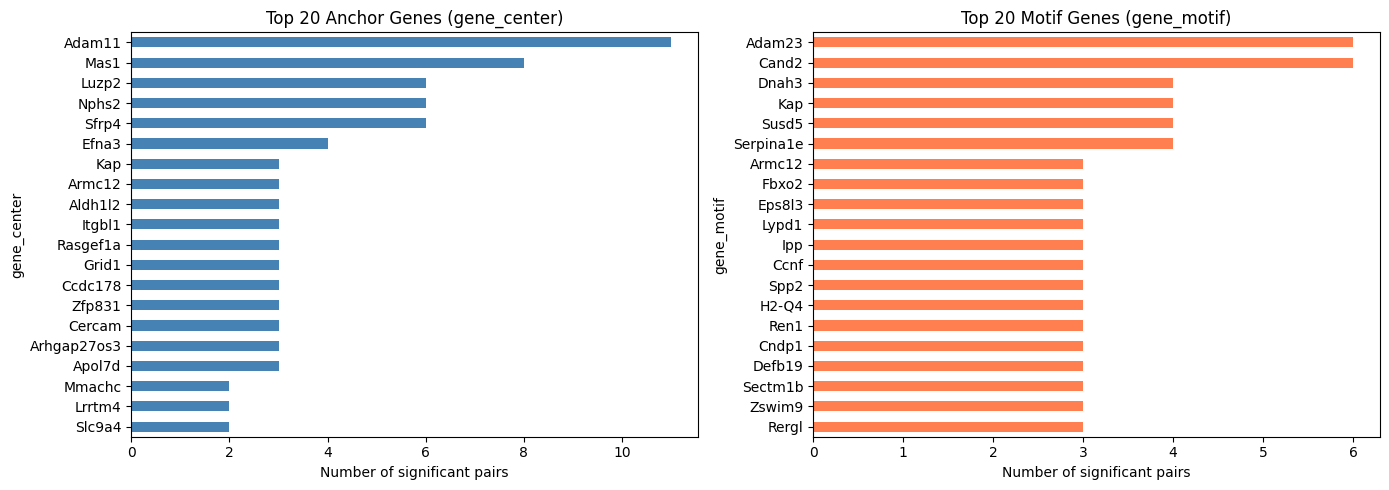

In [12]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

covarying_pooled_sig["gene_center"].value_counts().head(top_n).plot.barh(
    ax=axes[0], color="steelblue")
axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
axes[0].set_xlabel("Number of significant pairs")
axes[0].invert_yaxis()

covarying_pooled_sig["gene_motif"].value_counts().head(top_n).plot.barh(
    ax=axes[1], color="coral")
axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
axes[1].set_xlabel("Number of significant pairs")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Method 2: Per-cell-type Covariation (`compute_gene_gene_correlation_by_type`)

`compute_gene_gene_correlation_by_type` tests each **non-anchor cell type separately**,
so the output includes a `cell_type` column.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `dataset` | Condition name(s) to restrict the analysis to. If `None`, uses all datasets |
| `genes` | List of genes to analyze. If `None`, uses intersection of genes across FOVs |
| `max_dist` | Neighborhood radius (use either `max_dist` or `k`) |
| `k` | Number of nearest neighbors (use either `max_dist` or `k`) |
| `min_size` | Minimum neighborhood size for each anchor cell |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |
| `alpha` | FDR significance threshold (default: 0.05) |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `cell_type` | The neighbor cell type in the pair |
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

In [13]:
covarying = spm.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif,
    dataset=ds_case,
    max_dist=max_dist,
    genes=selected_genes[ds_case],
    alpha=0.05,
)

covarying_sig = covarying[covarying["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying)}")
print(f"Significant covarying pairs: {len(covarying_sig)}")

Computing covarying genes using expression data ...
Analyzing 2 non-center cell types in motif: ['kidney interstitial fibroblast', 'kidney loop of Henle thick ascending limb epithelial cell']
Selected 24 FOVs for analysis
Gene coverage: 14390 genes in all FOVs, 18795 genes total (union)
  -> 4405 genes present in subset of FOVs (will use available data)
Analyzing 3000 genes across 24 FOVs

Step 1: Computing Correlation-3 (Center without motif vs Neighbors)
...(137 lines omitted)...
Total gene pairs tested: 15536862
Significant covarying pairs: 3501


### Top Frequent Genes in Covarying Pairs (Per Cell Type)

For `compute_gene_gene_correlation_by_type`, visualize the top 20 genes
separately for each neighbor cell type.

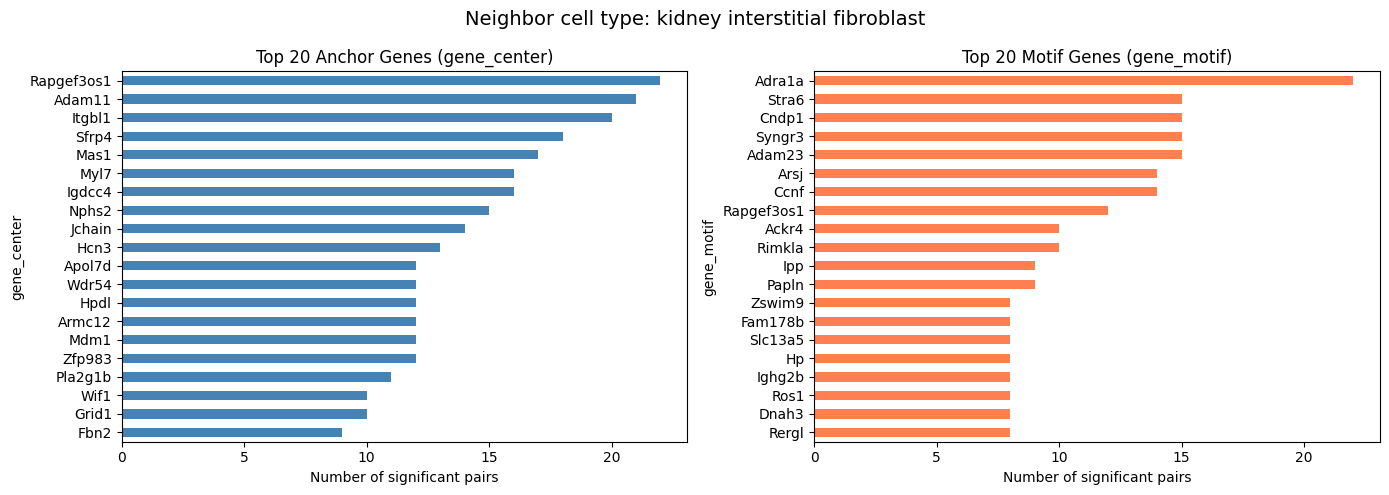

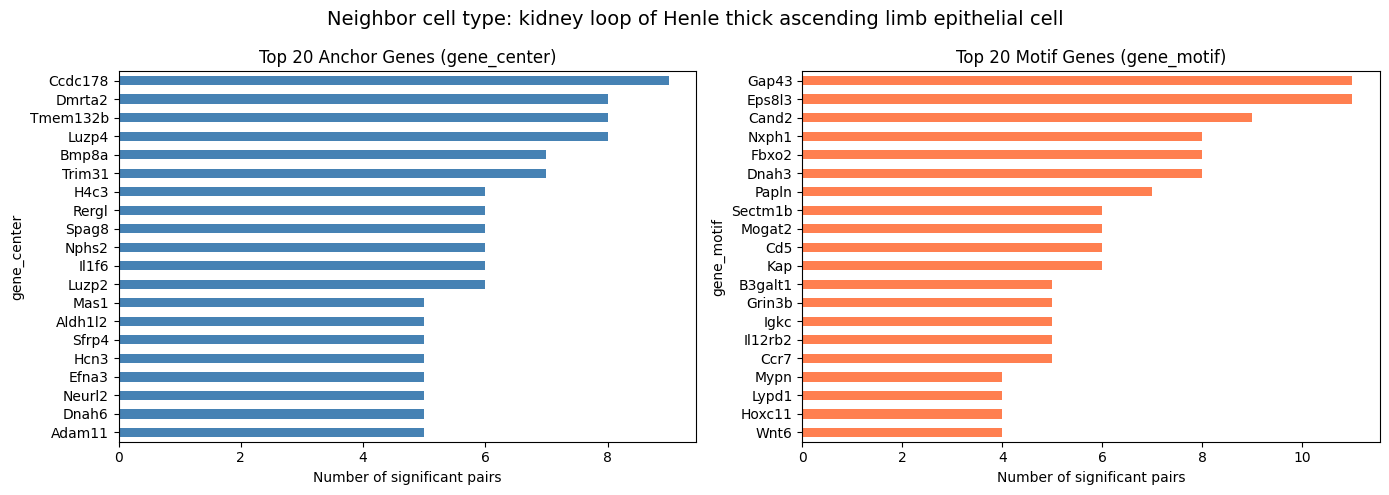

In [14]:
top_n = 20
cell_types = covarying_sig["cell_type"].unique()

for ct in cell_types:
    ct_df = covarying_sig[covarying_sig["cell_type"] == ct]
    if len(ct_df) == 0:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Neighbor cell type: {ct}", fontsize=14)

    ct_df["gene_center"].value_counts().head(top_n).plot.barh(
        ax=axes[0], color="steelblue")
    axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
    axes[0].set_xlabel("Number of significant pairs")
    axes[0].invert_yaxis()

    ct_df["gene_motif"].value_counts().head(top_n).plot.barh(
        ax=axes[1], color="coral")
    axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
    axes[1].set_xlabel("Number of significant pairs")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## Summary by Neighbor Cell Type

In [15]:
covarying_sig["cell_type"].value_counts()

cell_type
kidney interstitial fibroblast                               2525
kidney loop of Henle thick ascending limb epithelial cell     976
Name: count, dtype: int64

## Inspect Top Covarying Gene Pairs

Sort by combined score (absolute value) to see the strongest associations.

In [16]:
covarying_sig.sort_values("abs_combined_score", ascending=False).head(10)

,cell_type,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,q_value_test1,q_value_test2,reject_test1_fdr,reject_test2_fdr,abs_combined_score,if_significant
0,kidney interstitial fibroblast,Wif1,Lmo3,0.815627,-0.020971,0.0,0.836598,-0.000371,0.0,0.815997,246.653183,0.0,0.0,True,True,246.653183,True
1,kidney interstitial fibroblast,Wif1,Wif1,0.786223,-0.035668,0.0,0.821892,-0.000243,0.0,0.786467,239.128233,0.0,0.0,True,True,239.128233,True
2,kidney interstitial fibroblast,Armc12,Lmo3,0.748789,-0.020264,0.0,0.769053,-0.000078,0.0,0.748867,226.476755,0.0,0.0,True,True,226.476755,True
3,kidney interstitial fibroblast,Rapgef3os1,Slamf1,0.742925,-0.017139,0.0,0.760064,-0.000098,0.0,0.743023,224.440595,0.0,0.0,True,True,224.440595,True
4,kidney interstitial fibroblast,Armc12,Wif1,0.721795,-0.034466,0.0,0.756261,-0.000126,0.0,0.721921,219.666989,0.0,0.0,True,True,219.666989,True
5,kidney interstitial fibroblast,Luzp2,Serpina1e,0.699316,-0.024935,0.0,0.724251,0.005572,0.0,0.693744,210.868927,0.0,0.0,True,True,210.868927,True
6,kidney interstitial fibroblast,Rapgef3os1,Cerox1,0.671484,-0.019855,0.0,0.691338,-0.000087,0.0,0.671571,203.250420,0.0,0.0,True,True,203.250420,True
7,kidney interstitial fibroblast,Fam178b,Ppp1r3d,0.601521,-0.000445,0.0,0.601967,-0.000137,0.0,0.601659,180.525313,0.0,0.0,True,True,180.525313,True
8,kidney interstitial fibroblast,Gap43,Best3,0.528982,-0.016956,0.0,0.545937,-0.000250,0.0,0.529231,160.272942,0.0,0.0,True,True,160.272942,True
9,kidney interstitial fibroblast,Cercam,Rergl,0.493953,-0.001935,0.0,0.495888,0.004272,0.0,0.489681,147.462958,0.0,0.0,True,True,147.462958,True


## Visualize Covarying Gene Modules

> **Note:** `plot_gene_pair_heatmap` is available on the single-dataset `spatial_query` class.
> For multi-dataset results, you can use the standalone plotting function from `SpatialQuery.plotting`
> or apply clustering directly to the result DataFrame.

kidney loop of Henle thick ascending limb epithelial cell: Skipping neg with 4 rows and 1 columns.


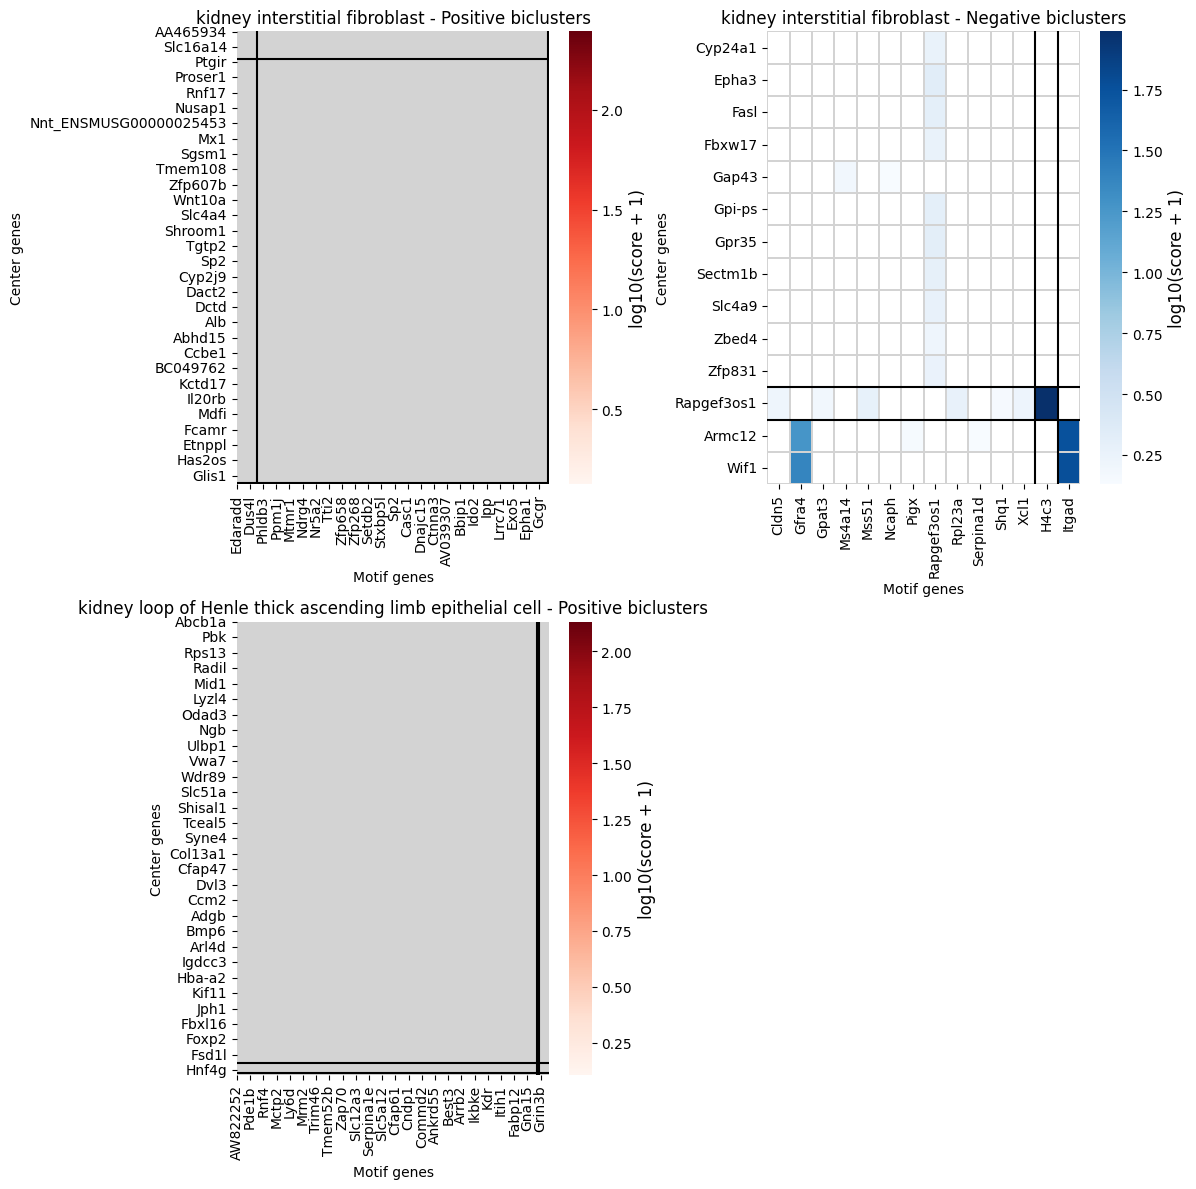

In [17]:
from SpatialQuery.plotting import plot_gene_pair_heatmap

if len(covarying_sig) > 0:
    modules = plot_gene_pair_heatmap(
        gene_pair_df=covarying_sig,
        figsize=(12, 6),
    )
else:
    print("No significant covarying gene pairs found.")

In [18]:
modules

,gene_center,gene_motif,combined_score,cluster_type,cluster_row,cluster_col,cell_type
0,AA465934,Adamts7,25.321869,positive,0,1,kidney interstitial fibroblast
1,AA465934,Il12rb2,26.951418,positive,0,1,kidney interstitial fibroblast
2,AA465934,Tmem143,1.009324,positive,0,1,kidney interstitial fibroblast
3,AA914427,Dgki,0.660621,positive,1,1,kidney interstitial fibroblast
4,AA914427,Iqcm,0.763277,positive,1,1,kidney interstitial fibroblast
...,...,...,...,...,...,...,...
3492,Zfp983,Eps8l3,42.379554,positive,0,2,kidney loop of Henle thick ascending limb epit...
3493,Zfp991,Nuggc,0.338234,positive,0,0,kidney loop of Henle thick ascending limb epit...
3494,Zfp992,B3galt1,0.399425,positive,0,0,kidney loop of Henle thick ascending limb epit...
3495,Zfp992,Sectm1b,0.568542,positive,0,0,kidney loop of Henle thick ascending limb epit...
